# `Compose(instance_binding=...)` — per-instance target alignment

New in **AlbumentationsX 2.2.0**.

Historically Albumentations treated `masks`, `bboxes` and `keypoints` as independent arrays. When a spatial transform dropped an instance (e.g. `RandomCrop` made it too small) only the bbox row was removed — the corresponding mask plane and keypoints were left behind, breaking index alignment with downstream models. Pose models also lost individual keypoints to `filter_keypoints` regardless of whether the host instance still existed.

`instance_binding` introduces a structured `instances` input format (a list of per-object dicts) and routes survival through the bbox processor, so every mask / bbox / keypoint belonging to a dropped instance disappears together. The output is repacked as `instances=[...]` with the same shape you fed in, minus dropped rows.

This notebook covers:

1. **Format A** — instance masks stacked as `(N, H, W)` (`instance_binding=["masks", "bboxes"]`).
2. **Format B** — multi-channel mask `(H, W, N)` (`instance_binding=["mask", "bboxes"]`).
3. **Format C** — bboxes + keypoints, no masks (`instance_binding=["bboxes", "keypoints"]`).
4. **Instance survival** — what happens when a transform crops out an instance entirely.
5. **`CopyAndPaste`** — the new mixing transform, used together with `instance_binding`.

Data: a tiny 128-image COCO subset (`coco128-seg`, ~7 MB) with real instance segmentation polygons.

## Heads-up: 2.2.0 API conventions

Two breaking changes you'll trip over coming from 2.1.x:

- Every sampling-range parameter ends in `_range` (e.g. `Rotate.angle_range`, `Blur.blur_range`, `HueSaturationValue.hue_shift_range`). The old `*_limit` names are gone.
- Range parameters are **tuples only**. Scalar shorthand (`A.Rotate(angle_range=30)`) is no longer accepted — pass `(-30, 30)` explicitly.

Also: `bbox_labels` / `keypoint_labels` inside instance dicts are reserved keys and must be `dict[label_field, value]`. Bare lists raise `TypeError` now.

In [ ]:
!pip install -q 'albumentationsx>=2.2.2' matplotlib


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
from __future__ import annotations

import io
import urllib.request
import zipfile
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

print("albumentations", A.__version__)

albumentations 2.2.2


## 1. Load a COCO mini sample

`coco128-seg` is the 128-image subset Ultralytics ships for smoke-testing YOLO segmentation. Labels are YOLO-format polygons (one line per instance: `class_idx x1 y1 x2 y2 ... xn yn`, normalized to `[0, 1]`). We rasterize each polygon into a binary mask and derive a tight bbox.

In [ ]:
DATA_ROOT = Path("../data/coco128-seg")
DATASET_URL = "https://www.ultralytics.com/assets/coco128-seg.zip"


def ensure_dataset() -> Path:
    if DATA_ROOT.exists() and any(DATA_ROOT.glob("images/train2017/*.jpg")):
        return DATA_ROOT
    DATA_ROOT.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading {DATASET_URL} ...")
    with urllib.request.urlopen(DATASET_URL) as resp:
        buf = io.BytesIO(resp.read())
    with zipfile.ZipFile(buf) as zf:
        zf.extractall(DATA_ROOT.parent)
    return DATA_ROOT


ensure_dataset()
image_paths = sorted(DATA_ROOT.glob("images/train2017/*.jpg"))
print(f"{len(image_paths)} images available")

128 images available


In [ ]:
COCO_NAMES = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat", "traffic light",
    "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove", "skateboard", "surfboard",
    "tennis racket", "bottle", "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana", "apple",
    "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch",
    "potted plant", "bed", "dining table", "toilet", "tv", "laptop", "mouse", "remote", "keyboard",
    "cell phone", "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase",
    "scissors", "teddy bear", "hair drier", "toothbrush",
]


def load_sample(image_path: Path) -> tuple[np.ndarray, list[dict]]:
    """Load one coco128-seg sample as (image, instances).

    Each instance dict has the shape required by `instance_binding=['masks','bboxes']`:
        - mask:        (H, W) uint8 binary mask
        - bbox:        np.ndarray([x1, y1, x2, y2]) in pascal_voc, in pixel coords
        - bbox_labels: {'class_name': str}
    """
    image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    label_path = DATA_ROOT / "labels" / "train2017" / (image_path.stem + ".txt")
    instances: list[dict] = []
    if not label_path.exists():
        return image, instances
    for line in label_path.read_text().splitlines():
        parts = line.split()
        if len(parts) < 7:
            continue
        class_idx = int(parts[0])
        coords = np.array(parts[1:], dtype=np.float32).reshape(-1, 2)
        coords[:, 0] *= w
        coords[:, 1] *= h
        polygon = coords.round().astype(np.int32)
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(mask, [polygon], 1)
        if mask.sum() == 0:
            continue
        ys, xs = np.where(mask > 0)
        bbox = np.array([xs.min(), ys.min(), xs.max() + 1, ys.max() + 1], dtype=np.float32)
        instances.append({
            "mask": mask,
            "bbox": bbox,
            "bbox_labels": {"class_name": COCO_NAMES[class_idx]},
        })
    return image, instances


PRIMARY_PATH = next(p for p in image_paths if len(load_sample(p)[1]) >= 3)
primary_image, primary_instances = load_sample(PRIMARY_PATH)
print(f"Primary: {PRIMARY_PATH.name}  shape={primary_image.shape}  instances={len(primary_instances)}")
for inst in primary_instances:
    print("  ", inst["bbox_labels"]["class_name"], inst["bbox"].tolist(), "mask area", int(inst["mask"].sum()))

Primary: 000000000009.jpg  shape=(480, 640, 3)  instances=8
   bowl [1.0, 188.0, 614.0, 475.0] mask area 121117
   bowl [312.0, 4.0, 632.0, 234.0] mask area 44845
   broccoli [250.0, 229.0, 567.0, 475.0] mask area 50000
   bowl [0.0, 14.0, 435.0, 390.0] mask area 25407
   orange [376.0, 40.0, 453.0, 88.0] mask area 2340
   orange [466.0, 39.0, 525.0, 87.0] mask area 1737
   orange [386.0, 74.0, 471.0, 145.0] mask area 3714
   orange [364.0, 2.0, 460.0, 75.0] mask area 3150


In [ ]:
_RNG = np.random.default_rng(0)
_COLOR_CACHE: dict[int, tuple[float, float, float]] = {}


def _color_for(idx: int) -> tuple[float, float, float]:
    if idx not in _COLOR_CACHE:
        _COLOR_CACHE[idx] = tuple(_RNG.uniform(0.3, 1.0, size=3))
    return _COLOR_CACHE[idx]


def draw_instances(ax: plt.Axes, image: np.ndarray, instances: list[dict], title: str = "") -> None:
    overlay = image.astype(np.float32).copy()
    for i, inst in enumerate(instances):
        color = np.array(_color_for(i)) * 255
        mask = inst.get("mask")
        if mask is not None:
            blend = (mask > 0)[..., None]
            overlay = np.where(blend, 0.5 * overlay + 0.5 * color, overlay)
    ax.imshow(np.clip(overlay, 0, 255).astype(np.uint8))
    for i, inst in enumerate(instances):
        x1, y1, x2, y2 = inst["bbox"]
        color = _color_for(i)
        ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=2))
        label = inst.get("bbox_labels", {}).get("class_name", "?")
        ax.text(x1, max(0, y1 - 4), label, color="white", fontsize=9,
                bbox=dict(facecolor=color, alpha=0.8, edgecolor="none", pad=1))
        kps = inst.get("keypoints")
        if kps is not None and len(kps) > 0:
            kps = np.asarray(kps)
            ax.scatter(kps[:, 0], kps[:, 1], c=[color], s=40, edgecolors="black", linewidths=0.8, zorder=5)
    ax.set_title(title)
    ax.axis("off")

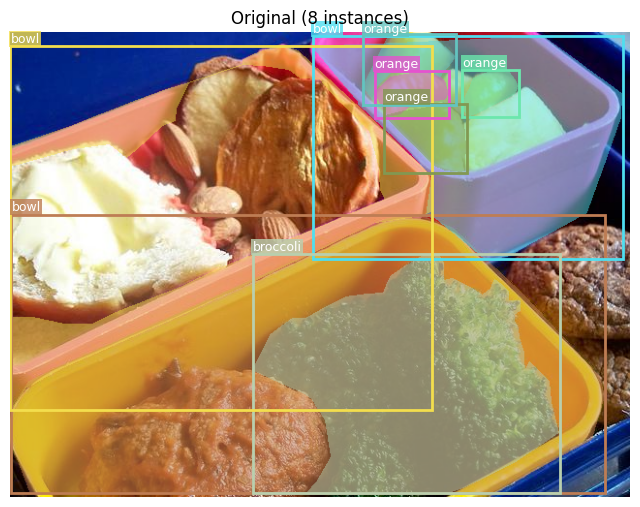

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
draw_instances(ax, primary_image, primary_instances, title=f"Original ({len(primary_instances)} instances)")
plt.show()

## 2. Format A — instance masks `(N, H, W)`

`instance_binding=["masks", "bboxes"]` packs the per-instance masks into a single `(N, H, W)` tensor before transforms run, then unpacks them back into per-instance dicts. Use this when your model expects one mask plane per instance (Mask R-CNN-style heads, panoptic decoders, etc.).

in: 8 instances  ->  out: 8 instances
out['instances'] is a list of dicts with the same keys you fed in:
  keys: ['bbox', 'bbox_labels', 'mask']


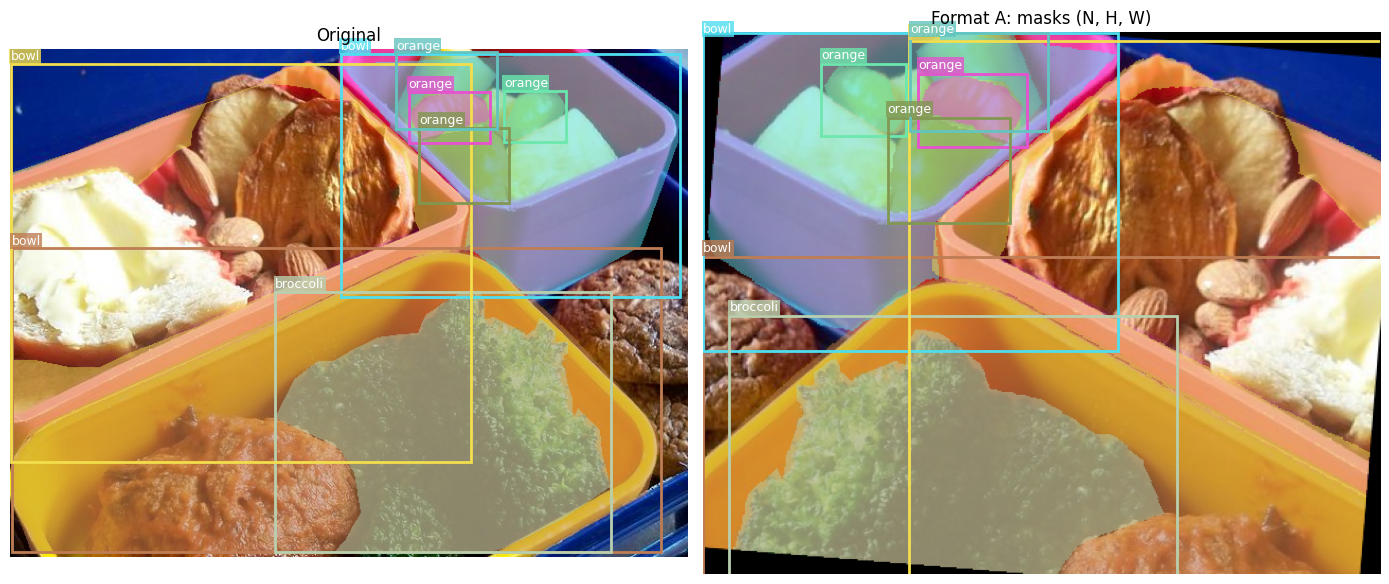

In [ ]:
transform_a = A.Compose(
    [
        A.HorizontalFlip(p=1.0),
        A.RandomCrop(height=400, width=500, p=1.0),
        A.Affine(rotate=(-30, 30), p=1.0),
    ],
    bbox_params=A.BboxParams(coord_format="pascal_voc", label_fields=["class_name"]),
    instance_binding=["masks", "bboxes"],
    seed=42,
)

out_a = transform_a(image=primary_image, instances=primary_instances)
print(f"in: {len(primary_instances)} instances  ->  out: {len(out_a['instances'])} instances")
print("out['instances'] is a list of dicts with the same keys you fed in:")
print("  keys:", sorted(out_a['instances'][0].keys()))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
draw_instances(axes[0], primary_image, primary_instances, title="Original")
draw_instances(axes[1], out_a["image"], out_a["instances"], title="Format A: masks (N, H, W)")
plt.tight_layout()
plt.show()

## 3. Format B — multi-channel mask `(H, W, N)`

Same input, one-line change: `instance_binding=["mask", "bboxes"]`. Internally the per-instance masks are stacked along the **last** axis, producing a single `mask` tensor of shape `(H, W, N)` instead of `masks` `(N, H, W)`. This is what older Keras / TF segmentation pipelines often expect.

`mask` and `masks` are mutually exclusive in `instance_binding` — pick exactly one.

In [ ]:
transform_b = A.Compose(
    [A.HorizontalFlip(p=1.0), A.RandomCrop(height=400, width=500, p=1.0)],
    bbox_params=A.BboxParams(coord_format="pascal_voc", label_fields=["class_name"]),
    instance_binding=["mask", "bboxes"],
    seed=42,
)

out_b = transform_b(image=primary_image, instances=primary_instances)
print(f"in: {len(primary_instances)} -> out: {len(out_b['instances'])}")
print("per-instance mask shape (Format B):", out_b["instances"][0]["mask"].shape)
print("per-instance mask shape (Format A):", out_a["instances"][0]["mask"].shape)
print("Same data, different packing.")

in: 8 -> out: 8
per-instance mask shape (Format B): (400, 500)
per-instance mask shape (Format A): (400, 500)
Same data, different packing.


## 4. Format C — bboxes + keypoints (no masks)

When you only have boxes and keypoints — typical for pose tasks — bind those two and skip masks entirely. To make the demo concrete we synthesize 2 keypoints per instance: bbox center + top-left corner.

in: 8 -> out: 8
   bowl bbox [20.5, 130.9, 500.0, 400.0] kps [[330.3999938964844, 284.1000061035156], [632.2000122070312, 130.89999389648438]] kp_labels {'kp_kind': ['center', 'tl']}
   bowl bbox [0.0, 0.0, 323.8, 196.9] kps [[159.3000030517578, 76.9000015258789], [315.5, -43.099998474121094]] kp_labels {'kp_kind': ['center', 'tl']}
   broccoli bbox [68.8, 179.8, 393.4, 400.0] kps [[230.10000610351562, 307.79998779296875], [384.6000061035156, 179.8000030517578]] kp_labels {'kp_kind': ['center', 'tl']}


/var/folders/68/k137nch11m76w1plfrw320r00000gn/T/ipykernel_2205/3882028838.py:15: UserWarning: label_fields are set but label_mapping is not provided. If you don't need label swapping, remove label_fields. If you need label swapping, provide label_mapping.
  keypoint_params=A.KeypointParams(coord_format="xy", label_fields=["kp_kind"]),


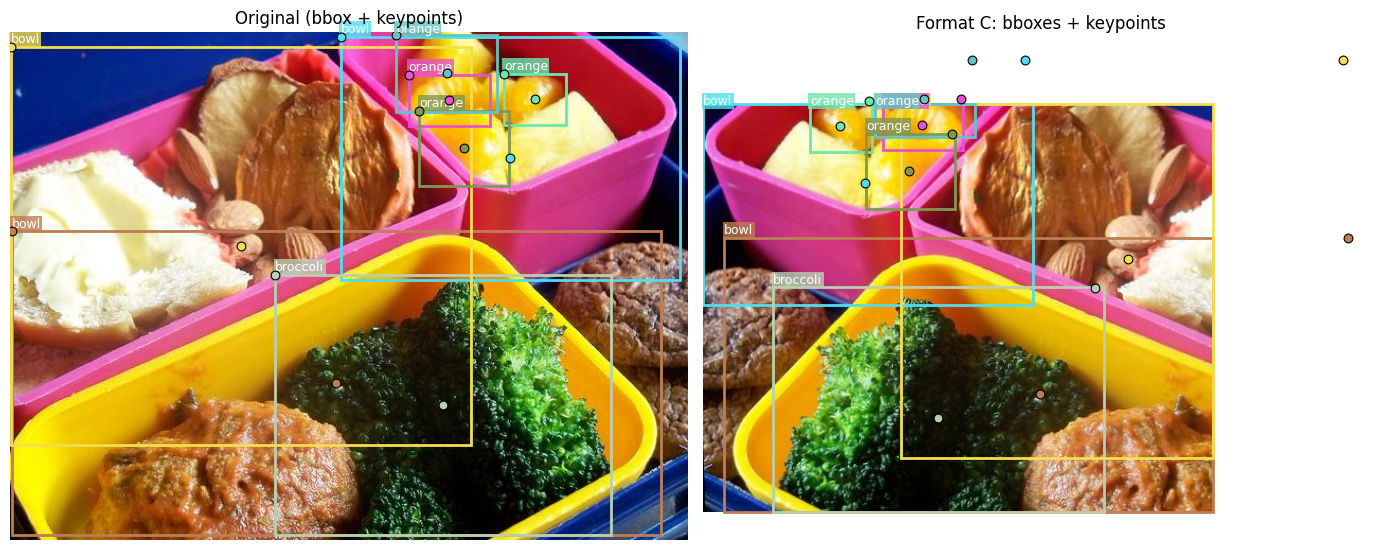

In [ ]:
instances_c = []
for inst in primary_instances:
    x1, y1, x2, y2 = inst["bbox"]
    kps = np.array([[(x1 + x2) / 2, (y1 + y2) / 2], [x1, y1]], dtype=np.float32)
    instances_c.append({
        "bbox": inst["bbox"],
        "keypoints": kps,
        "bbox_labels": {"class_name": inst["bbox_labels"]["class_name"]},
        "keypoint_labels": {"kp_kind": ["center", "tl"]},
    })

transform_c = A.Compose(
    [A.HorizontalFlip(p=1.0), A.Affine(rotate=(-20, 20), p=1.0), A.RandomCrop(height=400, width=500, p=1.0)],
    bbox_params=A.BboxParams(coord_format="pascal_voc", label_fields=["class_name"]),
    keypoint_params=A.KeypointParams(coord_format="xy", label_fields=["kp_kind"]),
    instance_binding=["bboxes", "keypoints"],
    seed=42,
)

out_c = transform_c(image=primary_image, instances=instances_c)
print(f"in: {len(instances_c)} -> out: {len(out_c['instances'])}")
for inst in out_c["instances"][:3]:
    print("  ", inst["bbox_labels"]["class_name"], "bbox", inst["bbox"].round(1).tolist(),
          "kps", inst["keypoints"].round(1).tolist(),
          "kp_labels", inst["keypoint_labels"])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
draw_instances(axes[0], primary_image, instances_c, title="Original (bbox + keypoints)")
draw_instances(axes[1], out_c["image"], out_c["instances"], title="Format C: bboxes + keypoints")
plt.tight_layout()
plt.show()

**Important nuance for Format C:** when keypoints are bound, `KeypointParams.remove_invisible` and `check_each_transform` are forced to `False`. Out-of-frame keypoints stick around — only **instance survival** (driven by the bbox processor) decides what gets dropped. That keeps each surviving instance's keypoint count constant, which is what pose models want.

## 5. Instance survival under aggressive cropping

Hammer the image with a tiny random crop and watch instances disappear from the output list. The bbox processor's `min_visibility`, `min_area`, etc. drive who lives — masks and keypoints follow.

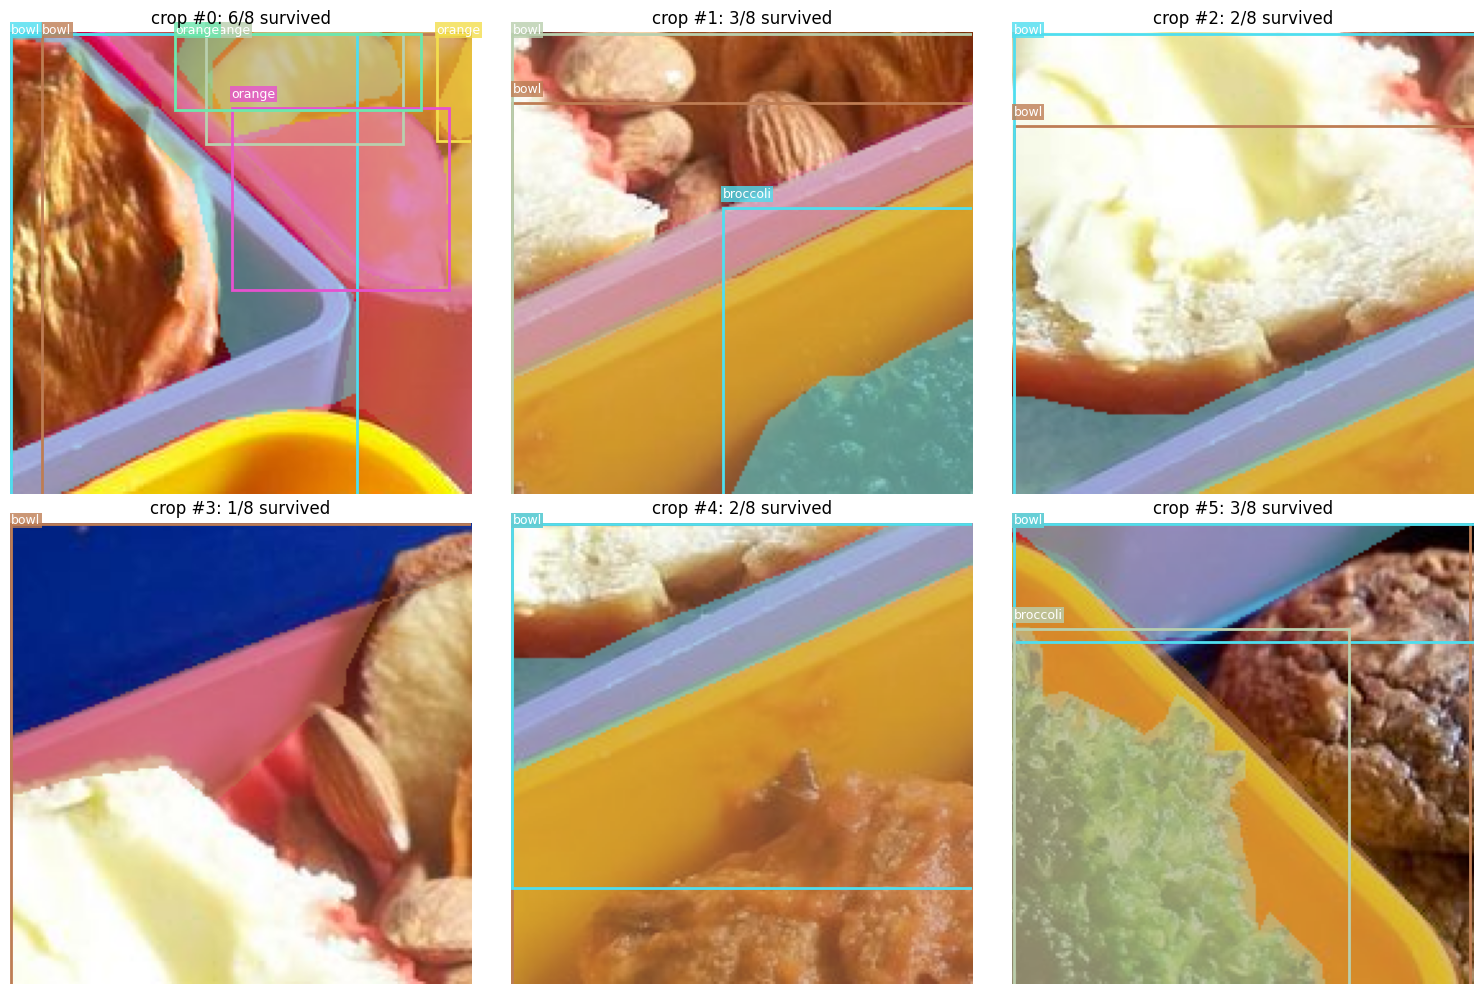

In [ ]:
transform_survival = A.Compose(
    [A.RandomCrop(height=180, width=180, p=1.0)],
    bbox_params=A.BboxParams(coord_format="pascal_voc", label_fields=["class_name"], min_visibility=0.1),
    instance_binding=["masks", "bboxes"],
    seed=7,
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for i, ax in enumerate(axes):
    out = transform_survival(image=primary_image, instances=primary_instances)
    draw_instances(ax, out["image"], out["instances"], title=f"crop #{i}: {len(out['instances'])}/{len(primary_instances)} survived")
plt.tight_layout()
plt.show()

## 6. `CopyAndPaste` with bound instances

[`CopyAndPaste`](https://explore.albumentations.ai/transform/CopyAndPaste) is the new mixing transform in 2.2.0. It pastes donor objects onto the primary image, updating masks / bboxes / keypoints. Donors are passed via `copy_paste_metadata` as a `list[dict]` — one dict per object, mirroring the per-instance dict format used by `instance_binding`.

Key contract:

- Each donor is **tight-cropped** to its mask (or bbox if mask is absent), then **shrink-fit** into the target with aspect preserved (no upscaling), then optionally jittered by `scale_range`, then stamped at a uniformly random location.
- Existing primary instances whose visible area drops below `min_visibility_after_paste` after occlusion are removed from the output.
- Pasted rows get fresh ids (`max(existing_ids) + 1`) so they slot in cleanly with `instance_binding`.

Below: pick a different image as the donor pool, paste a few of its instances onto our primary.

primary: 8  donors offered: 3  output instances: 11
   bowl bbox [26.0, 188.0, 639.0, 475.0]
   bowl bbox [8.0, 4.0, 328.0, 234.0]
   broccoli bbox [73.0, 229.0, 390.0, 475.0]
   bowl bbox [205.0, 14.0, 640.0, 390.0]
   orange bbox [187.0, 40.0, 264.0, 88.0]
   orange bbox [115.0, 39.0, 174.0, 87.0]
   orange bbox [169.0, 74.0, 254.0, 145.0]
   orange bbox [180.0, 2.0, 276.0, 75.0]
   horse bbox [104.0, 377.0, 174.0, 476.0]
   horse bbox [558.0, 346.0, 603.0, 431.0]
   person bbox [604.0, 44.0, 640.0, 84.0]


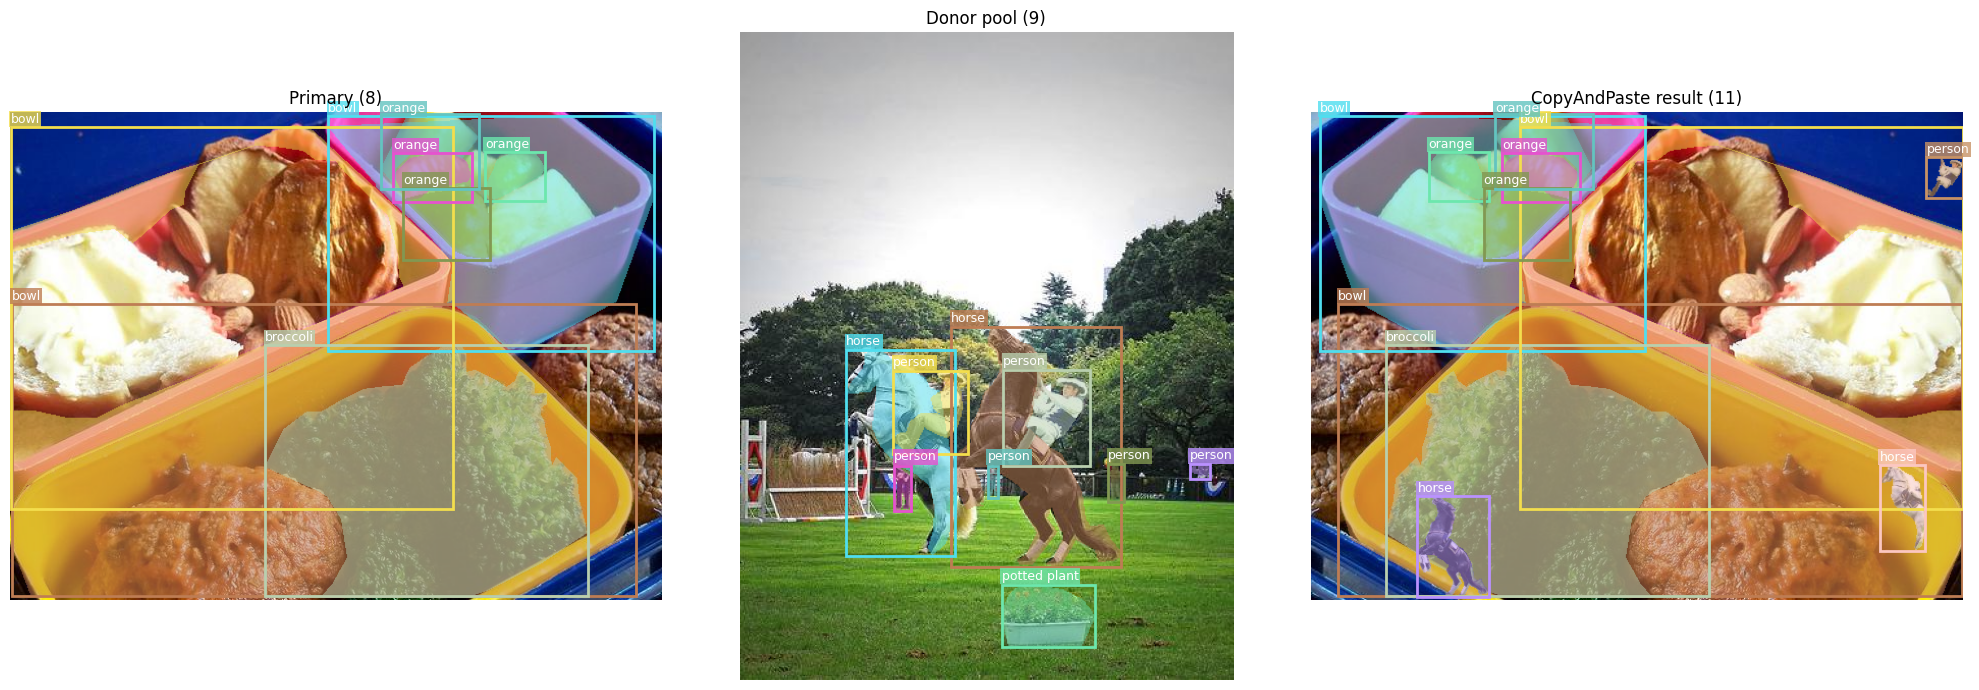

In [ ]:
DONOR_PATH = next(p for p in image_paths if p != PRIMARY_PATH and len(load_sample(p)[1]) >= 3)
donor_image, donor_instances = load_sample(DONOR_PATH)

donors = [
    {
        "image": donor_image,
        "mask": inst["mask"],
        "bbox_labels": {"class_name": inst["bbox_labels"]["class_name"]},
    }
    for inst in donor_instances[:3]
]

transform_cp = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.CopyAndPaste(
            scale_range=(0.4, 1.0),
            blend_mode="gaussian",
            blend_sigma_range=(1.0, 2.0),
            min_visibility_after_paste=0.1,
            p=1.0,
        ),
    ],
    bbox_params=A.BboxParams(coord_format="pascal_voc", label_fields=["class_name"]),
    instance_binding=["masks", "bboxes"],
    seed=42,
)

out_cp = transform_cp(
    image=primary_image,
    instances=primary_instances,
    copy_paste_metadata=donors,
)

print(f"primary: {len(primary_instances)}  donors offered: {len(donors)}  output instances: {len(out_cp['instances'])}")
for inst in out_cp["instances"]:
    print("  ", inst["bbox_labels"]["class_name"], "bbox", inst["bbox"].round(1).tolist())

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
draw_instances(axes[0], primary_image, primary_instances, title=f"Primary ({len(primary_instances)})")
draw_instances(axes[1], donor_image, donor_instances, title=f"Donor pool ({len(donor_instances)})")
draw_instances(axes[2], out_cp["image"], out_cp["instances"], title=f"CopyAndPaste result ({len(out_cp['instances'])})")
plt.tight_layout()
plt.show()

## TL;DR

- `Compose(instance_binding=[...])` keeps masks / bboxes / keypoints aligned per instance through the whole pipeline — including [`Mosaic`](https://explore.albumentations.ai/transform/Mosaic) and [`CopyAndPaste`](https://explore.albumentations.ai/transform/CopyAndPaste).
- Pass instances as `instances=[{...}, ...]`. Get them back the same shape via `out["instances"]`.
- Pick `"masks"` for `(N, H, W)` packing, `"mask"` for `(H, W, N)`. They're mutually exclusive.
- `bbox_labels` and `keypoint_labels` inside instance dicts are **dicts** keyed by `BboxParams.label_fields` / `KeypointParams.label_fields`. A bare list raises `TypeError` in 2.2.0.
- For an end-to-end YOLO-style training pipeline (`Mosaic` + `CopyAndPaste` + `Affine` + flip + HSV) on top of `instance_binding`, see [`example_yolo_style_pipeline.ipynb`](example_yolo_style_pipeline.ipynb).